<style>
.jp-RenderedHTMLCommon table, .dataframe {font-size: 0.95em;}
.jp-RenderedHTMLCommon h1 {border-bottom: 3px solid #1f5f99; padding-bottom: 6px;}
.jp-RenderedHTMLCommon h2 {border-bottom: 1px solid #9fb9d1; padding-bottom: 4px;}
</style>

# Chapter 3 Interactive Instructor Notebook: Determinants

**Course:** MATH 3260 — Linear Algebra  
**Sections:** 3.1–3.4  
**Audience:** Instructor version

This notebook develops determinants computationally, algebraically, and geometrically. It includes detailed hand calculations, computational verification, applications, classroom questions, and individual instructor answer reveals.

> **Design rule:** establish the mathematics first; use Python to verify, visualize, or extend the mathematics rather than replace the written reasoning.

> **How to use this notebook in class**
>
> Run the notebook from top to bottom before class. Pause at each **Classroom Question**, **Classroom Check**, or section worksheet and give students time to work before clicking **Reveal answer**.
>
> Click the same button again to hide the answer. Complete solutions are stored in a hidden instructor answer bank rather than printed openly in the scrolling notebook.
>
> Display mathematics uses ordinary Markdown/LaTeX rather than raw HTML containers so that equations render reliably in JupyterLab, classic Jupyter Notebook, VS Code, and Colab.

## Chapter map

1. **Section 3.1:** The Determinant of a Matrix  
2. **Section 3.2:** Determinants and Elementary Operations  
3. **Section 3.3:** Properties of Determinants  
4. **Section 3.4:** Applications of Determinants  

Each section ends with a terminology table, a worksheet, and complete instructor solutions.

In [1]:
# Local environment check, imports, and classroom reveal helper.
import sys, platform, importlib.util
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Math, HTML

required_packages = ["numpy", "sympy", "matplotlib"]
missing_packages = [name for name in required_packages if importlib.util.find_spec(name) is None]
if missing_packages:
    raise ModuleNotFoundError(
        "Missing packages: " + ", ".join(missing_packages) +
        ". Install them before running this notebook."
    )

try:
    import ipywidgets as widgets
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print("ipywidgets is unavailable. A dependency-free HTML reveal button will be used instead.")

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    pass

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

sp.init_printing()
np.set_printoptions(precision=4, suppress=True)


def reveal_answer(answer_markdown, button_text="Reveal answer"):
    """Create a click-to-reveal / click-to-hide answer button."""
    if not WIDGETS_AVAILABLE:
        import uuid
        try:
            import mistune
            answer_html = mistune.html(answer_markdown)
        except Exception:
            import html as _html
            answer_html = "<pre>" + _html.escape(answer_markdown) + "</pre>"
        box_id = "answer_" + uuid.uuid4().hex
        btn_id = "button_" + uuid.uuid4().hex
        safe_label = button_text.replace('"', '&quot;')
        html_block = f"""
        <div style='margin:8px 0 14px 0;'>
          <button id='{btn_id}'
            style='padding:6px 12px;border:1px solid #4b87b9;border-radius:5px;background:#eef6ff;cursor:pointer;font-weight:600;'
            onclick="var box=document.getElementById('{box_id}'); var btn=document.getElementById('{btn_id}');
                     if(box.style.display==='none'){{box.style.display='block';btn.innerText='Hide answer';
                     if(window.MathJax && MathJax.typesetPromise){{MathJax.typesetPromise([box]);}}}}
                     else{{box.style.display='none';btn.innerText='{safe_label}';}}">
            {safe_label}
          </button>
          <div id='{box_id}' style='display:none;margin-top:10px;padding:10px 12px;border-left:4px solid #4b87b9;background:#fafcff;'>
            {answer_html}
          </div>
        </div>
        """
        display(HTML(html_block))
        return None

    button = widgets.ToggleButton(
        value=False,
        description=button_text,
        icon="eye",
        button_style="info",
        layout=widgets.Layout(width="190px")
    )
    out = widgets.Output()
    def _toggle(change):
        out.clear_output(wait=True)
        if change["new"]:
            button.description = "Hide answer"
            button.icon = "eye-slash"
            with out:
                display(Markdown(answer_markdown))
        else:
            button.description = button_text
            button.icon = "eye"
    button.observe(_toggle, names="value")
    display(widgets.VBox([button, out]))
    return button


def reveal_answer_key(key, button_text="Reveal answer"):
    """Reveal an answer stored in CH3_ANSWERS without exposing it in the classroom cell."""
    return reveal_answer(CH3_ANSWERS[key], button_text=button_text)


def show_matrix(M, label=None):
    """Display a SymPy matrix with an optional LaTeX label."""
    M = sp.Matrix(M)
    if label:
        display(Math(rf"{label}={sp.latex(M)}"))
    else:
        display(M)
    return M


def det2_steps(M, label='A'):
    """Show the complete 2-by-2 determinant calculation."""
    M = sp.Matrix(M)
    if M.shape != (2, 2):
        raise ValueError('M must be 2 by 2.')
    a, b, c, d = M[0,0], M[0,1], M[1,0], M[1,1]
    display(Math(rf"{label}={sp.latex(M)}"))
    display(Math(rf"\det({label})=({sp.latex(a)})({sp.latex(d)})-({sp.latex(b)})({sp.latex(c)})={sp.latex(M.det())}"))
    return M.det()


def minor_matrix(A, i, j):
    """Return the submatrix after deleting row i and column j (0-based Python indices)."""
    A = sp.Matrix(A)
    return A.minor_submatrix(i, j)


def all_minors_and_cofactors(A):
    """Return the minor matrix and cofactor matrix of a square matrix."""
    A = sp.Matrix(A)
    if A.rows != A.cols:
        raise ValueError('A must be square.')
    n = A.rows
    minors = sp.zeros(n)
    cofactors = sp.zeros(n)
    for i in range(n):
        for j in range(n):
            minors[i,j] = A.minor_submatrix(i,j).det()
            cofactors[i,j] = (-1)**(i+j) * minors[i,j]
    return minors, cofactors


def triangle_area(points):
    """Area of a triangle in the xy-plane from three points."""
    if len(points) != 3:
        raise ValueError('Exactly three points are required.')
    M = sp.Matrix([[x, y, 1] for x, y in points])
    return sp.Abs(M.det()) / 2


def tetrahedron_volume(points):
    """Volume of a tetrahedron from four 3D points."""
    if len(points) != 4:
        raise ValueError('Exactly four points are required.')
    M = sp.Matrix([[x, y, z, 1] for x, y, z in points])
    return sp.Abs(M.det()) / 6

print(f"Python {sys.version.split()[0]} on {platform.system()} — Chapter 3 environment is ready.")

Python 3.13.15 on Linux — Chapter 3 environment is ready.


In [2]:
CH3_ANSWERS = {'3.1-1': '$$\n\\det\\begin{bmatrix}7&2\\\\3&5\\end{bmatrix}\n=7(5)-2(3)=35-6=29.\n$$', '3.1-2': 'The minor matrix is\n\n$$\n[M_{ij}]=\n\\begin{bmatrix}\n-9&7&5\\\\\n10&5&-3\\\\\n8&4&-7\n\\end{bmatrix}.\n$$\n\nApplying the checkerboard signs gives\n\n$$\n[C_{ij}]=\n\\begin{bmatrix}\n-9&-7&5\\\\\n-10&5&3\\\\\n8&-4&-7\n\\end{bmatrix}.\n$$', '3.1-3': 'Expand along the first row:\n\n$$\n\\det(A)=4\\det\\begin{bmatrix}3&0\\\\5&1\\end{bmatrix}\n+2\\det\\begin{bmatrix}1&3\\\\0&5\\end{bmatrix}.\n$$\n\nThe signs in positions $(1,1)$ and $(1,3)$ are both positive, so\n\n$$\n\\det(A)=4(3)+2(5)=22.\n$$', '3.1-4': 'The matrix is lower triangular, so\n\n$$\n\\det(A)=2(3)(-2)(5)=-60.\n$$', '3.1-5': 'The two columns form the sides of the transformed parallelogram. When the determinant is zero, the signed area scale is zero, so the two transformed edge vectors lie along the same line (or one is the zero vector). Therefore the parallelogram collapses to a line segment or point. Later in the course, we will describe this redundancy formally by saying that the columns are **linearly dependent**.', '3.2-1': 'Begin with\n\n$$\nA=\\begin{bmatrix}3&1&2\\\\6&5&1\\\\0&4&7\\end{bmatrix}.\n$$\n\nApply $R_2\\leftarrow R_2-2R_1$:\n\n$$\n\\begin{bmatrix}3&1&2\\\\0&3&-3\\\\0&4&7\\end{bmatrix}.\n$$\n\nApply $R_3\\leftarrow 3R_3-4R_2$. This operation combines a row scaling and a row replacement. Let us track it carefully. First, multiplying row 3 by $3$ multiplies the determinant by $3$. Then subtracting $4R_2$ does not change it:\n\n$$\n\\begin{bmatrix}3&1&2\\\\0&3&-3\\\\0&0&33\\end{bmatrix}.\n$$\n\nThe determinant of the final matrix is $3(3)(33)=297$. Therefore,\n\n$$\n3\\det(A)=297,\n$$\n\nso\n\n$$\n\\det(A)=99.\n$$', '3.2-2': '- after one row interchange: $6$;\n- after multiplying one row by $-3$: $(-3)(-6)=18$;\n- after a row replacement: $-6$.', '3.2-3': 'Row 2 is twice row 1:\n\n$$\nR_2=2R_1.\n$$\n\nApply\n\n$$\nR_2\\leftarrow R_2-2R_1.\n$$\n\nThis creates a zero row, and row replacement does not change the determinant. A matrix with a zero row has determinant zero. Thus\n\n$$\n\\boxed{\\det(A)=0}.\n$$\n\nLater, this kind of redundancy will be formalized as linear dependence.', '3.2-4': 'Column 2 is three times column 1. Apply $C_2\\leftarrow C_2-3C_1$ to obtain a zero column. Therefore, the determinant is zero.', '3.2-5': 'If one column equals the sum of two other columns, that column contributes no new independent direction. Subtracting those two columns from it creates a zero column using determinant-preserving column replacements. Therefore\n\n$$\n\\boxed{\\det(A)=0}.\n$$\n\nHence the square matrix is singular and is not invertible. Later, we will call this relationship among the columns **linear dependence**.', '3.3-1': '$$\n\\det(AB)=\\det(A)\\det(B)=4(-3)=-12.\n$$\n\nAlso,\n\n$$\n\\det(BA)=\\det(B)\\det(A)=-12.\n$$\n\nBecause $A$ is $3\\times3$,\n\n$$\n\\det(2A)=2^3\\det(A)=8(4)=32.\n$$\n\nFinally,\n\n$$\n\\det(B^{-1})=\\frac{1}{\\det(B)}=-\\frac13.\n$$', '3.3-2': 'Because $2AB^{-1}$ is a scalar multiple of a $3\\times3$ matrix,\n\n$$\n\\det(2AB^{-1})\n=2^3\\det(A)\\det(B^{-1})\n=8(4)\\left(-\\frac13\\right)\n=-\\frac{32}{3}.\n$$', '3.3-3': '$C$ is singular, so $C^{-1}$ does not exist. The homogeneous system has at least one nontrivial solution.', '3.3-4': '$$\n(-2)(5)=-10.\n$$\n\nThe magnitude of the area scale is $10$, and the negative sign means orientation is reversed.', '3.3-5': '$$\n\\det((D^T)^3)=\\det(D^T)^3=\\det(D)^3=(-2)^3=-8.\n$$', '3.4-1': 'For\n\n$$\nA=\\begin{bmatrix}2&1\\\\5&3\\end{bmatrix},\n$$\n\nwe have\n\n$$\n\\operatorname{adj}(A)=\\begin{bmatrix}3&-1\\\\-5&2\\end{bmatrix}\n$$\n\nand\n\n$$\n\\det(A)=2(3)-1(5)=1.\n$$\n\nTherefore,\n\n$$\nA^{-1}=\\begin{bmatrix}3&-1\\\\-5&2\\end{bmatrix}.\n$$', '3.4-2': 'The coefficient matrix is\n\n$$\nA=\\begin{bmatrix}1&1&1\\\\2&-1&1\\\\1&2&-1\\end{bmatrix}.\n$$\n\nIts determinant is\n\n$$\nD=7.\n$$\n\nReplacing the first, second, and third columns by the constant vector gives\n\n$$\nD_x=14,\n\\qquad\nD_y=21,\n\\qquad\nD_z=28.\n$$\n\nThus\n\n$$\nx=2,\n\\qquad y=3,\n\\qquad z=4.\n$$', '3.4-3': 'Use the determinant area formula:\n\n$$\n\\text{Area}\n=\\frac12\\left|\n\\det\\begin{bmatrix}\n0&1&1\\\\\n6&2&1\\\\\n2&7&1\n\\end{bmatrix}\n\\right|.\n$$\n\nExpanding along the first row,\n\n$$\n\\det\\begin{bmatrix}\n0&1&1\\\\\n6&2&1\\\\\n2&7&1\n\\end{bmatrix}\n=0\n-1\\det\\begin{bmatrix}6&1\\\\2&1\\end{bmatrix}\n+1\\det\\begin{bmatrix}6&2\\\\2&7\\end{bmatrix}.\n$$\n\nThus\n\n$$\n=-(6-2)+(42-4)\n=-4+38\n=34.\n$$\n\nTherefore,\n\n$$\n\\boxed{\\text{Area}=\\frac12|34|=17}.\n$$\n\nSo the triangle has area $17$ square units.', '3.4-4': '$$\n\\det\\begin{bmatrix}x&y&1\\\\1&4&1\\\\5&12&1\\end{bmatrix}=0.\n$$\n\nExpanding gives\n\n$$\n-8x+4y-8=0,\n$$\n\nso\n\n$$\ny=2x+2.\n$$', '3.4-5': '$$\nV=\\frac16|4(3)(2)|=4.\n$$', '3.4-6': 'Direction vectors are\n\n$$\n(3,0,1)-(1,1,0)=(2,-1,1),\n$$\n\nand\n\n$$\n(0,2,2)-(1,1,0)=(-1,1,2).\n$$\n\nTheir cross product is\n\n$$\n(2,-1,1)\\times(-1,1,2)=(-3,-5,1).\n$$\n\nUsing $(1,1,0)$,\n\n$$\n-3(x-1)-5(y-1)+z=0,\n$$\n\nso an equation is\n\n$$\n3x+5y-z=8.\n$$', 'concept-3.1-sign': 'From the three examples,\n\n$$\n\\det(A)=169>0,\\qquad \\det(B)=0,\\qquad \\det(C)=-37<0.\n$$\n\nTherefore:\n\n- $A$ has nonzero area scale and preserves orientation;\n- $B$ has zero area scale, collapses the plane to a lower-dimensional set, and is not invertible;\n- $C$ has nonzero area scale and reverses orientation.\n\nThe magnitude $|\\det|$ gives the area scale; the sign records orientation.', 'concept-3.1-orientation': 'The ordered pair $(\\mathbf e_1,\\mathbf e_2)$ has\n\n$$\n\\det\\begin{bmatrix}1&0\\\\0&1\\end{bmatrix}=1>0,\n$$\n\nso it has the standard counterclockwise orientation. Reversing the order gives $(\\mathbf e_2,\\mathbf e_1)$ and swaps two columns:\n\n$$\n\\det\\begin{bmatrix}0&1\\\\1&0\\end{bmatrix}=-1<0.\n$$\n\nThus reversing the order reverses orientation. Orientation belongs to an **ordered pair** of vectors, not to two unlabeled vectors.', 'concept-3.1-cofactor': 'For position $(1,2)$,\n\n$$\n(-1)^{1+2}=-1.\n$$\n\nSince\n\n$$\nM_{12}=-9,\n$$\n\nthe cofactor is\n\n$$\nC_{12}=(-1)M_{12}=(-1)(-9)=\\boxed{9}.\n$$', 'concept-3.1-expansion': 'Choose the **third column** because it contains three zeros and only one nonzero entry, $q_{33}=7$. Cofactor expansion therefore reduces immediately to one term:\n\n$$\n\\det(Q)=7C_{33}.\n$$\n\nThe sign at $(3,3)$ is positive because $(-1)^{3+3}=1$.', 'concept-3.1-triangular': 'For a triangular matrix, multiply the diagonal entries:\n\n$$\n\\det(T)=(-2)(4)(3)=\\boxed{-24}.\n$$\n\nThe magnitude $24$ is the volume-scale factor in $\\mathbb R^3$, and the negative sign indicates reversed orientation.', 'concept-3.2-operations': 'Start with $\\det(A)=5$.\n\n1. Swap two rows:\n   $$5\\longrightarrow -5.$$\n2. Multiply one row by $-2$:\n   $$-5\\longrightarrow (-2)(-5)=10.$$\n3. Add a multiple of one row to another:\n   $$10\\longrightarrow 10.$$\n\nTherefore the final determinant is\n\n$$\n\\boxed{10}.\n$$', 'concept-3.2-zero-column': 'If one column is three times another, say $C_2=3C_1$, then\n\n$$\nC_2\\leftarrow C_2-3C_1\n$$\n\ncreates a zero column without changing the determinant. A matrix with a zero column has determinant zero. Therefore\n\n$$\n\\boxed{\\det(A)=0}.\n$$', 'concept-3.3-product': 'Use multiplicativity:\n\n$$\n\\det(AB)=\\det(A)\\det(B)=(-2)(5)=\\boxed{-10}.\n$$\n\nAlso,\n\n$$\n\\det(BA)=\\det(B)\\det(A)=5(-2)=\\boxed{-10}.\n$$\n\nThis equality of determinants does **not** mean that $AB=BA$.', 'concept-3.3-scalar': 'Because $A$ is $4\\times4$,\n\n$$\n\\det(2A)=2^4\\det(A)=16(3)=\\boxed{48}.\n$$\n\nThe exponent is $4$ because multiplying the whole matrix by $2$ multiplies each of its four rows by $2$.', 'concept-3.3-inverse': 'Since $\\det(A)=-4\\neq0$, $A$ is invertible. Therefore\n\n$$\n\\det(A^{-1})=\\frac{1}{\\det(A)}=\\boxed{-\\frac14}.\n$$', 'concept-3.3-transpose': 'Transposition preserves the determinant:\n\n$$\n\\det(R^T)=\\det(R)=\\boxed{7}.\n$$\n\nThis is why every determinant rule stated for rows has a corresponding rule for columns.', 'concept-3.4-adjugate': 'The **cofactor matrix** keeps each cofactor $C_{ij}$ in position $(i,j)$:\n\n$$\nC=[C_{ij}].\n$$\n\nThe **adjugate** is the transpose of that matrix:\n\n$$\n\\operatorname{adj}(A)=C^T.\n$$\n\nThus the two matrices are generally different; the adjugate interchanges the row and column positions of the cofactors.', 'concept-3.4-cramer': "Cramer's Rule requires a square coefficient matrix with\n\n$$\n\\det(A)\\neq0.\n$$\n\nIf $\\det(A)=0$, the denominators\n\n$$\n\\frac{\\det(A_i)}{\\det(A)}\n$$\n\nwould involve division by zero, so Cramer's Rule cannot be used to produce a unique solution.", 'concept-3.4-collinear': 'If the determinant in the triangle-area formula is zero, then\n\n$$\n\\text{Area}=\\frac12|0|=0.\n$$\n\nThe three points do not form a genuine triangle; they lie on one line. Thus the points are **collinear**.', 'concept-3.4-line': 'The determinant is zero because the three row vectors\n\n$$\n[x\\;y\\;1],\\qquad [x_1\\;y_1\\;1],\\qquad [x_2\\;y_2\\;1]\n$$\n\nrepresent three points that lie on the same line. Geometrically, the triangle determined by the three points has area zero. The determinant equation is therefore an algebraic way to impose collinearity.', 'concept-3.4-plane': 'For a point $(x,y,z)$ to lie in the same plane as three fixed noncollinear points, the four points must form a tetrahedron of volume zero. The determinant\n\n$$\n\\det\\begin{bmatrix}\nx&y&z&1\\\\\nx_1&y_1&z_1&1\\\\\nx_2&y_2&z_2&1\\\\\nx_3&y_3&z_3&1\n\\end{bmatrix}\n$$\n\nis therefore zero exactly when the four points are coplanar.'}
print(f'Loaded {len(CH3_ANSWERS)} Chapter 3 instructor answer keys.')

Loaded 37 Chapter 3 instructor answer keys.


> **Notebook workflow**
>
> The mathematical explanation comes first. Python cells are optional verification or visualization. Classroom questions and worksheets are followed by individual answer buttons so solutions remain hidden until you choose to reveal them.

> **Example policy**
>
> All worked examples and numerical values are original. Personal-interest themes are used selectively, including the Spurs, hiking, travel, badminton, driving, Backstreet Boys, and R&B music. Any prices, route coordinates, or datasets are fictional teaching models unless explicitly identified otherwise.

# Section 3.1 - The Determinant of a Matrix

## Learning objectives

By the end of this section, students should be able to:

- compute the determinant of a $2\times2$ matrix;
- interpret a determinant as signed area scaling;
- find minors and cofactors;
- use cofactor expansion along any row or column;
- select an efficient expansion row or column;
- evaluate determinants of triangular matrices.

> **Definition: Determinant of a $2\times2$ Matrix**
>
> For
>
> $$
> A=\begin{bmatrix}a&b\\c&d\end{bmatrix},
> $$
>
> the determinant is
>
> $$
> \boxed{\det(A)=ad-bc}.
> $$
>
> The notation $|A|$ is also used for the determinant, but it should not be confused with the absolute value of a number. The formula $ad-bc$ applies specifically to a $2\times2$ matrix.

## Original example: three $2\times2$ determinants

Consider

$$
A=\begin{bmatrix}9&1\\20&21\end{bmatrix},
\qquad
B=\begin{bmatrix}4&6\\2&3\end{bmatrix},
\qquad
C=\begin{bmatrix}-2&5\\7&1\end{bmatrix}.
$$

For $A$,

$$
\det(A)=9(21)-1(20)=189-20=169.
$$

For $B$,

$$
\det(B)=4(3)-6(2)=12-12=0.
$$

For $C$,

$$
\det(C)=(-2)(1)-5(7)=-2-35=-37.
$$

A zero determinant signals that the corresponding linear transformation collapses area and is not invertible.

### Classroom Check: What Does the Sign Tell Us?

For the three matrices above, $\det(A)=169$, $\det(B)=0$, and $\det(C)=-37$.

What does each value tell us about area scaling, orientation, and invertibility?

In [3]:
reveal_answer_key("concept-3.1-sign", 'Reveal interpretation')

ToggleButton(value=False, button_style='info', description='Reveal interpretation', icon='eye', layout=Layout(…

In [4]:
A31a = sp.Matrix([[9,1],[20,21]])
B31a = sp.Matrix([[4,6],[2,3]])
C31a = sp.Matrix([[-2,5],[7,1]])

det2_steps(A31a, 'A')
det2_steps(B31a, 'B')
det2_steps(C31a, 'C')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

-37

## Geometric Meaning: Signed Area Scaling and Orientation

For a $2\times2$ matrix

$$
A=
\begin{bmatrix}
\mathbf a_1 & \mathbf a_2
\end{bmatrix},
$$

the columns

$$
\mathbf a_1
\qquad\text{and}\qquad
\mathbf a_2
$$

have a natural geometric meaning.

Recall the standard basis vectors

$$
\mathbf e_1=
\begin{bmatrix}
1\\
0
\end{bmatrix},
\qquad
\mathbf e_2=
\begin{bmatrix}
0\\
1
\end{bmatrix}.
$$

Because

$$
A\mathbf e_1=\mathbf a_1,
\qquad
A\mathbf e_2=\mathbf a_2,
$$

the columns of $A$ are exactly the images of the standard basis vectors under the transformation defined by $A$.

The vectors

$$
\mathbf a_1
\qquad\text{and}\qquad
\mathbf a_2
$$

form the two edge vectors of a parallelogram.

The area of that parallelogram is

$$
\boxed{|\det(A)|}.
$$

Therefore,

$$
\boxed{
|\det(A)|
=
\text{area scale factor}
}.
$$

For example:

- if $|\det(A)|=3$, every two-dimensional area is multiplied by $3$;
- if $|\det(A)|=\frac12$, every area is reduced by a factor of $\frac12$;
- if $|\det(A)|=1$, area is preserved;
- if $\det(A)=0$, two-dimensional area collapses completely.

However, the **sign** of the determinant contains additional geometric information.

It tells us whether the transformation preserves or reverses **orientation**.

---

### The Standard Orientation

The ordered pair

$$
(\mathbf e_1,\mathbf e_2)
$$

is taken as the standard positive orientation in $\mathbb R^2$.

Geometrically,

$$
\mathbf e_1=
\begin{bmatrix}
1\\
0
\end{bmatrix}
$$

points to the right, while

$$
\mathbf e_2=
\begin{bmatrix}
0\\
1
\end{bmatrix}
$$

points upward.

If we rotate from $\mathbf e_1$ toward $\mathbf e_2$ through the smaller angle, the rotation is **counterclockwise**.

Therefore,

$$
\boxed{
(\mathbf e_1,\mathbf e_2)
\text{ has counterclockwise orientation}.
}
$$

Indeed,

$$
\det
\begin{bmatrix}
\mathbf e_1&\mathbf e_2
\end{bmatrix}
=
\det
\begin{bmatrix}
1&0\\
0&1
\end{bmatrix}
=
1>0.
$$

So a **positive determinant corresponds to the same orientation as the standard basis**.

---

## Orientation After Applying a Matrix

Suppose

$$
A=
\begin{bmatrix}
a&b\\
c&d
\end{bmatrix}.
$$

Then

$$
A\mathbf e_1=
\begin{bmatrix}
a\\
c
\end{bmatrix}
=
\mathbf a_1,
$$

and

$$
A\mathbf e_2=
\begin{bmatrix}
b\\
d
\end{bmatrix}
=
\mathbf a_2.
$$

Therefore, to determine whether $A$ preserves or reverses orientation, compare the ordered pair

$$
(\mathbf e_1,\mathbf e_2)
$$

with

$$
(\mathbf a_1,\mathbf a_2).
$$

Ask the following question:

> Starting from the first column $\mathbf a_1$, do we rotate counterclockwise or clockwise to reach the second column $\mathbf a_2$ through the smaller angle?

This leads to three possibilities.

---

### Case 1: $\det(A)>0$ — Orientation Is Preserved

If

$$
\det(A)>0,
$$

then the ordered pair

$$
(\mathbf a_1,\mathbf a_2)
$$

has the same counterclockwise orientation as

$$
(\mathbf e_1,\mathbf e_2).
$$

Thus,

$$
\boxed{
\det(A)>0
\Longrightarrow
\text{orientation is preserved}.
}
$$

For example, let

$$
A=
\begin{bmatrix}
2&1\\
1&2
\end{bmatrix}.
$$

Then

$$
\mathbf a_1=
\begin{bmatrix}
2\\
1
\end{bmatrix},
\qquad
\mathbf a_2=
\begin{bmatrix}
1\\
2
\end{bmatrix}.
$$

The determinant is

$$
\det(A)
=
2(2)-1(1)
=
3>0.
$$

Geometrically, rotating from

$$
\mathbf a_1=
\begin{bmatrix}
2\\
1
\end{bmatrix}
$$

toward

$$
\mathbf a_2=
\begin{bmatrix}
1\\
2
\end{bmatrix}
$$

is counterclockwise.

So the transformation preserves orientation.

Also,

$$
|\det(A)|=3,
$$

so areas are scaled by a factor of $3$.

Thus this transformation both

- preserves orientation;
- multiplies area by $3$.

---

### Case 2: $\det(A)<0$ — Orientation Is Reversed

If

$$
\det(A)<0,
$$

then the ordered pair

$$
(\mathbf a_1,\mathbf a_2)
$$

has the opposite orientation from

$$
(\mathbf e_1,\mathbf e_2).
$$

Instead of counterclockwise, the ordered pair is clockwise.

Therefore,

$$
\boxed{
\det(A)<0
\Longrightarrow
\text{orientation is reversed}.
}
$$

For example, consider

$$
A=
\begin{bmatrix}
1&0\\
0&-1
\end{bmatrix}.
$$

Then

$$
\mathbf a_1=
\begin{bmatrix}
1\\
0
\end{bmatrix},
\qquad
\mathbf a_2=
\begin{bmatrix}
0\\
-1
\end{bmatrix}.
$$

The determinant is

$$
\det(A)
=
1(-1)-0(0)
=
-1.
$$

Now, starting from

$$
\mathbf a_1=
\begin{bmatrix}
1\\
0
\end{bmatrix},
$$

we rotate **clockwise** to reach

$$
\mathbf a_2=
\begin{bmatrix}
0\\
-1
\end{bmatrix}.
$$

Thus the orientation has been reversed.

Geometrically, this matrix reflects the plane across the $x$-axis.

Notice that

$$
|\det(A)|=1,
$$

so area is preserved even though orientation is reversed.

This illustrates the difference between the magnitude and sign of the determinant:

$$
\boxed{
|\det(A)|
=
\text{area scaling}
}
$$

while

$$
\boxed{
\operatorname{sign}(\det(A))
=
\text{orientation information}.
}
$$

---

### Case 3: $\det(A)=0$ — Area Collapses

If

$$
\det(A)=0,
$$

then the two columns of $A$ lie along the same line.

For example,

$$
A=
\begin{bmatrix}
1&2\\
2&4
\end{bmatrix}.
$$

Its columns are

$$
\mathbf a_1=
\begin{bmatrix}
1\\
2
\end{bmatrix},
\qquad
\mathbf a_2=
\begin{bmatrix}
2\\
4
\end{bmatrix}.
$$

But

$$
\mathbf a_2=2\mathbf a_1.
$$

Therefore, the two vectors lie on the same line.

Also,

$$
\det(A)
=
1(4)-2(2)
=
0.
$$

The parallelogram formed by the two columns has zero area.

Geometrically, a two-dimensional region has been flattened onto a line.

Thus,

$$
\boxed{
\det(A)=0
\Longrightarrow
\text{two-dimensional area collapses to zero}.
}
$$

Because the image no longer has two-dimensional area, there is no meaningful clockwise or counterclockwise orientation.

---

## How Do We Determine Counterclockwise or Clockwise Orientation?

Suppose we have two ordered vectors

$$
\mathbf u=
\begin{bmatrix}
u_1\\
u_2
\end{bmatrix},
\qquad
\mathbf v=
\begin{bmatrix}
v_1\\
v_2
\end{bmatrix}.
$$

The word **ordered** is important.

We place $\mathbf u$ first and $\mathbf v$ second:

$$
\begin{bmatrix}
\mathbf u&\mathbf v
\end{bmatrix}
=
\begin{bmatrix}
u_1&v_1\\
u_2&v_2
\end{bmatrix}.
$$

Then

$$
\det
\begin{bmatrix}
\mathbf u&\mathbf v
\end{bmatrix}
=
u_1v_2-u_2v_1.
$$

The sign tells us the orientation:

$$
\boxed{
\begin{array}{ccl}
u_1v_2-u_2v_1>0
&\Longrightarrow&
\mathbf u\rightarrow\mathbf v
\text{ is counterclockwise},
\\[2mm]
u_1v_2-u_2v_1<0
&\Longrightarrow&
\mathbf u\rightarrow\mathbf v
\text{ is clockwise},
\\[2mm]
u_1v_2-u_2v_1=0
&\Longrightarrow&
\mathbf u,\mathbf v
\text{ lie along the same line}.
\end{array}
}
$$

---

### Why Does the Order Matter?

Consider the standard basis in the usual order:

$$
(\mathbf e_1,\mathbf e_2).
$$

We have

$$
\det
\begin{bmatrix}
\mathbf e_1&\mathbf e_2
\end{bmatrix}
=
1.
$$

Thus the orientation is counterclockwise.

Now reverse the order:

$$
(\mathbf e_2,\mathbf e_1).
$$

Then

$$
\det
\begin{bmatrix}
\mathbf e_2&\mathbf e_1
\end{bmatrix}
=
\det
\begin{bmatrix}
0&1\\
1&0
\end{bmatrix}
=
-1.
$$

Now the orientation is clockwise.

Therefore,

$$
\boxed{
\text{swapping the two vectors reverses orientation}.
}
$$

This is also why interchanging two columns of a matrix changes the sign of its determinant.

---

## A Useful Visual Summary

The standard ordered basis has

$$
\mathbf e_1
\overset{\text{counterclockwise}}{\longrightarrow}
\mathbf e_2.
$$

After applying $A$, look at

$$
A\mathbf e_1
\qquad\text{and}\qquad
A\mathbf e_2.
$$

### Positive determinant

If

$$
A\mathbf e_1
\overset{\text{counterclockwise}}{\longrightarrow}
A\mathbf e_2,
$$

then

$$
\boxed{\det(A)>0}.
$$

The orientation is preserved.

### Negative determinant

If

$$
A\mathbf e_1
\overset{\text{clockwise}}{\longrightarrow}
A\mathbf e_2,
$$

then

$$
\boxed{\det(A)<0}.
$$

The orientation is reversed.

### Zero determinant

If

$$
A\mathbf e_1
\qquad\text{and}\qquad
A\mathbf e_2
$$

lie along the same line, then

$$
\boxed{\det(A)=0}.
$$

The two-dimensional area has collapsed.

---

> **Key Geometric Meaning of the Determinant**
>
> For a $2\times2$ matrix $A$,
>
> $$
> \boxed{
> |\det(A)|
> =
> \text{area scale factor}
> }
> $$
>
> while the sign gives orientation:
>
> $$
> \boxed{
> \begin{cases}
> \det(A)>0
> &\Rightarrow \text{orientation preserved},\\
> \det(A)<0
> &\Rightarrow \text{orientation reversed},\\
> \det(A)=0
> &\Rightarrow \text{area collapses and orientation is lost}.
> \end{cases}
> }
> $$
>
> A useful classroom question is:
>
> **From the first transformed basis vector $A\mathbf e_1$, which direction must we rotate to reach the second transformed basis vector $A\mathbf e_2$?**
>
> Counterclockwise means positive determinant; clockwise means negative determinant.

---

### Higher-Dimensional Viewpoint

The same idea extends to higher dimensions.

In $\mathbb R^3$,

$$
|\det(A)|
$$

is the **volume scale factor**.

For example, if

$$
|\det(A)|=5,
$$

then the volume of every three-dimensional region is multiplied by $5$.

The sign distinguishes the two possible orientations of an ordered basis:

- $\det(A)>0$: orientation is preserved;
- $\det(A)<0$: orientation is reversed.

In $\mathbb R^3$, these two possible orientations are often described as **right-handed** and **left-handed**.

For the standard basis

$$
(\mathbf e_1,\mathbf e_2,\mathbf e_3),
$$

we use the right-handed orientation as the positive orientation.

A convenient way to remember this is the right-hand rule:

- point the fingers of your right hand from $\mathbf e_1$ toward $\mathbf e_2$;
- your thumb points in the direction of $\mathbf e_3$.

Thus,

$$
\boxed{
\det(A)>0
}
$$

means that the transformed ordered basis keeps the same right-handed orientation, while

$$
\boxed{
\det(A)<0
}
$$

means that the transformation changes it to the opposite, left-handed orientation.

So in $\mathbb R^3$, the sign of the determinant tells us whether the transformation preserves or reverses the handedness of the coordinate system.

In general, for an $n\times n$ matrix,

$$
\boxed{
|\det(A)|
=
\text{$n$-dimensional volume scale factor}
}
$$

and

$$
\boxed{
\operatorname{sign}(\det(A))
=
\text{orientation information}.
}
$$

If

$$
\det(A)=0,
$$

the transformation collapses the space into a lower-dimensional object, so the original $n$-dimensional orientation is lost.

### Classroom Check: Ordered Orientation

Consider the standard basis vectors

$$
\mathbf e_1=\begin{bmatrix}1\\0\end{bmatrix},
\qquad
\mathbf e_2=\begin{bmatrix}0\\1\end{bmatrix}.
$$

What is the orientation of $(\mathbf e_1,\mathbf e_2)$? What happens if we reverse the order to $(\mathbf e_2,\mathbf e_1)$?

In [5]:
reveal_answer_key("concept-3.1-orientation", 'Reveal orientation check')

ToggleButton(value=False, button_style='info', description='Reveal orientation check', icon='eye', layout=Layo…

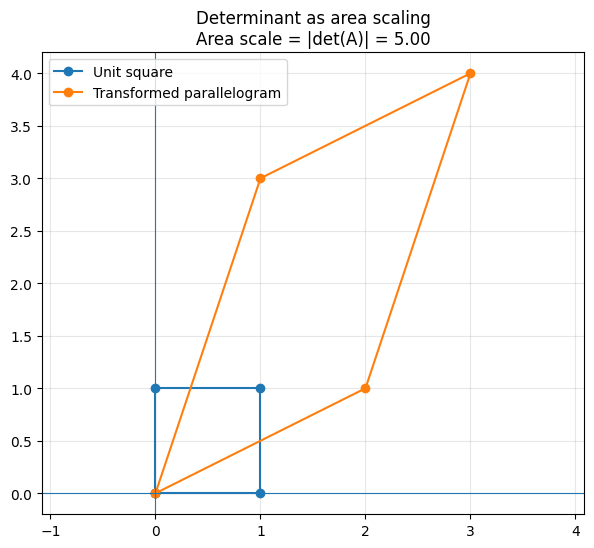

In [6]:
# Visualize the unit square and its image under a 2-by-2 matrix.
def plot_area_scaling(A, title='Determinant as area scaling'):
    A = np.array(A, dtype=float)
    square = np.array([[0,0],[1,0],[1,1],[0,1],[0,0]])
    transformed = square @ A.T

    plt.figure(figsize=(7,6))
    plt.plot(square[:,0], square[:,1], marker='o', label='Unit square')
    plt.plot(transformed[:,0], transformed[:,1], marker='o', label='Transformed parallelogram')
    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)
    plt.grid(alpha=0.3)
    plt.axis('equal')
    plt.title(f"{title}\nArea scale = |det(A)| = {abs(np.linalg.det(A)):.2f}")
    plt.legend()
    plt.show()

plot_area_scaling([[2,1],[1,3]])

> **Definition: Minor and Cofactor**
>
> For a square matrix $A$, the **minor** $M_{ij}$ is the determinant of the matrix obtained by deleting row $i$ and column $j$ from $A$.
>
> The corresponding **cofactor** is
>
> $$
> C_{ij}=(-1)^{i+j}M_{ij}.
> $$
>
> The cofactor signs follow the alternating checkerboard pattern
>
> $$
> \begin{bmatrix}
> +&-&+&\cdots\\
> -&+&-&\cdots\\
> +&-&+&\cdots\\
> \vdots&\vdots&\vdots&\ddots
> \end{bmatrix}.
> $$

The $3\times3$ cofactor sign pattern is

$$
\begin{bmatrix}
+&-&+\\
-&+&-\\
+&-&+
\end{bmatrix}.
$$

## Original example: all minors and cofactors

Let

$$
H=\begin{bmatrix}
2&1&0\\
-1&3&2\\
4&0&1
\end{bmatrix}.
$$

To find $M_{12}$, delete row 1 and column 2:

$$
M_{12}=\det\begin{bmatrix}-1&2\\4&1\end{bmatrix}
=(-1)(1)-2(4)=-9.
$$

Because $(-1)^{1+2}=-1$,

$$
C_{12}=-M_{12}=9.
$$

The complete minor matrix is

$$
[M_{ij}]=
\begin{bmatrix}
3&-9&-12\\
1&2&-4\\
2&4&7
\end{bmatrix},
$$

and the cofactor matrix is

$$
[C_{ij}]=
\begin{bmatrix}
3&9&-12\\
-1&2&4\\
2&-4&7
\end{bmatrix}.
$$

### Classroom Check: Minor or Cofactor?

For the matrix $H$ above, we found

$$
M_{12}=-9.
$$

Without recomputing the minor, determine $C_{12}$.

In [7]:
reveal_answer_key("concept-3.1-cofactor", 'Reveal cofactor check')

ToggleButton(value=False, button_style='info', description='Reveal cofactor check', icon='eye', layout=Layout(…

In [8]:
H = sp.Matrix([[2,1,0],[-1,3,2],[4,0,1]])
minors_H, cofactors_H = all_minors_and_cofactors(H)
show_matrix(H, 'H')
show_matrix(minors_H, '[M_{ij}]')
show_matrix(cofactors_H, '[C_{ij}]')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

⎡3   9   -12⎤
⎢           ⎥
⎢-1  2    4 ⎥
⎢           ⎥
⎣2   -4   7 ⎦

## Cofactor expansion

For an $n\times n$ matrix, expansion along row $i$ is

$$
\det(A)=a_{i1}C_{i1}+a_{i2}C_{i2}+\cdots+a_{in}C_{in}.
$$

Expansion along column $j$ is

$$
\det(A)=a_{1j}C_{1j}+a_{2j}C_{2j}+\cdots+a_{nj}C_{nj}.
$$

The determinant is the same regardless of the selected row or column. Choose a row or column containing many zeros.

### Detailed expansion of $H$ along the first row

Because the third entry in the first row is zero,

$$
\det(H)=2C_{11}+1C_{12}+0C_{13}.
$$

We already found $C_{11}=3$ and $C_{12}=9$, so

$$
\det(H)=2(3)+1(9)+0(-12)=15.
$$

In [9]:
print('det(H) =', H.det())
# Verify expansions along every row and every column.
for i in range(3):
    row_sum = sum(H[i,j] * H.cofactor(i,j) for j in range(3))
    print(f'Expansion along row {i+1}:', sp.simplify(row_sum))
for j in range(3):
    col_sum = sum(H[i,j] * H.cofactor(i,j) for i in range(3))
    print(f'Expansion along column {j+1}:', sp.simplify(col_sum))

det(H) = 15
Expansion along row 1: 15
Expansion along row 2: 15
Expansion along row 3: 15
Expansion along column 1: 15
Expansion along column 2: 15
Expansion along column 3: 15


## Original $4\times4$ example: exploit a sparse column

Let

$$
Q=
\begin{bmatrix}
2&1&0&3\\
0&-1&0&4\\
5&2&7&1\\
1&0&0&2
\end{bmatrix}.
$$

The third column has only one nonzero entry, $q_{33}=7$. Therefore,

$$
\det(Q)=7C_{33}.
$$

Since $(-1)^{3+3}=1$,

$$
C_{33}=\det\begin{bmatrix}
2&1&3\\
0&-1&4\\
1&0&2
\end{bmatrix}.
$$

Expand this $3\times3$ determinant along the second row. The middle entry is $-1$:

$$
(-1)(+1)\det\begin{bmatrix}2&3\\1&2\end{bmatrix}
=(-1)(4-3)=-1.
$$

The last entry is $4$ and its cofactor sign is negative:

$$
4(-1)\det\begin{bmatrix}2&1\\1&0\end{bmatrix}
=4(-1)(-1)=4.
$$

Therefore,

$$
C_{33}=-1+4=3.
$$

Hence

$$
\det(Q)=7(3)=21.
$$

### Classroom Question: Which Expansion Should We Choose?

For the $4\times4$ matrix $Q$, which row or column is the most efficient choice for cofactor expansion, and why? What is the cofactor sign at the only nonzero position in that row or column?

In [10]:
reveal_answer_key("concept-3.1-expansion", 'Reveal expansion strategy')

ToggleButton(value=False, button_style='info', description='Reveal expansion strategy', icon='eye', layout=Lay…

In [11]:
Q = sp.Matrix([[2,1,0,3],[0,-1,0,4],[5,2,7,1],[1,0,0,2]])
show_matrix(Q, 'Q')
print('det(Q) =', Q.det())
print('Minor M_33 =', Q.minor_submatrix(2,2).det())

<IPython.core.display.Math object>

det(Q) = 21
Minor M_33 = 3


> **Theorem: Determinant of a Triangular Matrix**
>
> If $A$ is upper triangular or lower triangular, then its determinant is the product of its diagonal entries:
>
> $$
> \boxed{\det(A)=a_{11}a_{22}\cdots a_{nn}}.
> $$
>
> Consequently, a triangular matrix is invertible if and only if every diagonal entry is nonzero.

For

$$
T=\begin{bmatrix}
3&0&0&0\\
-2&5&0&0\\
1&4&-2&0\\
7&1&6&4
\end{bmatrix},
$$

we have

$$
\det(T)=3(5)(-2)(4)=-120.
$$

### Classroom Check: Triangular Determinant

Suppose a $3\times3$ upper triangular matrix has diagonal entries

$$
-2,\quad 4,\quad 3.
$$

What is its determinant? What does the sign tell us geometrically?

In [61]:
reveal_answer_key("concept-3.1-triangular", 'Reveal triangular check')

ToggleButton(value=False, button_style='info', description='Reveal triangular check', icon='eye', layout=Layou…

In [13]:
T = sp.Matrix([[3,0,0,0],[-2,5,0,0],[1,4,-2,0],[7,1,6,4]])
show_matrix(T, 'T')
print('Product of diagonal entries =', sp.prod(T[i,i] for i in range(4)))
print('det(T) =', T.det())

<IPython.core.display.Math object>

Product of diagonal entries = -120
det(T) = -120


> **Common Mistakes**
>
> - Do not use $ad-bc$ for matrices larger than $2\times2$.
> - Do not forget the alternating cofactor signs.
> - During cofactor expansion, multiply each entry by its **cofactor** $C_{ij}$, not merely by its minor $M_{ij}$.
>
> Recall that
>
> $$
> C_{ij}=(-1)^{i+j}M_{ij}.
> $$
>
> - When choosing a row or column for expansion, look for one containing many zeros to reduce the amount of arithmetic.

## Definitions and terminology

| Term | Meaning |
|---|---|
| Determinant | Scalar associated with a square matrix |
| Signed area scale | Geometric interpretation of a $2\times2$ determinant |
| Minor $M_{ij}$ | Determinant after deleting row $i$ and column $j$ |
| Cofactor $C_{ij}$ | $(-1)^{i+j}M_{ij}$ |
| Cofactor expansion | Sum of entries times cofactors along a row or column |
| Upper triangular | Zeros below the main diagonal |
| Lower triangular | Zeros above the main diagonal |
| Diagonal matrix | Zeros above and below the main diagonal |

## Section 3.1 worksheet — in-class practice

Work each problem before revealing the instructor solution.

### Problem 1

Compute

$$
\det\begin{bmatrix}7&2\\3&5\end{bmatrix}.
$$

In [14]:
reveal_answer_key("3.1-1", "Reveal Problem 1")

ToggleButton(value=False, button_style='info', description='Reveal Problem 1', icon='eye', layout=Layout(width…

### Problem 2

For

$$
A=\begin{bmatrix}1&2&0\\3&-1&4\\2&1&5\end{bmatrix},
$$

find all minors and cofactors.

In [15]:
reveal_answer_key("3.1-2", "Reveal Problem 2")

ToggleButton(value=False, button_style='info', description='Reveal Problem 2', icon='eye', layout=Layout(width…

### Problem 3

Use cofactor expansion to evaluate

$$
\det\begin{bmatrix}4&0&2\\1&3&0\\0&5&1\end{bmatrix}.
$$

In [16]:
reveal_answer_key("3.1-3", "Reveal Problem 3")

ToggleButton(value=False, button_style='info', description='Reveal Problem 3', icon='eye', layout=Layout(width…

### Problem 4

Find the determinant of

$$
\begin{bmatrix}2&0&0&0\\-1&3&0&0\\4&5&-2&0\\7&1&6&5\end{bmatrix}.
$$

In [17]:
reveal_answer_key("3.1-4", "Reveal Problem 4")

ToggleButton(value=False, button_style='info', description='Reveal Problem 4', icon='eye', layout=Layout(width…

### Problem 5

Explain why a $2\times2$ matrix with determinant zero collapses area.

In [18]:
reveal_answer_key("3.1-5", "Reveal Problem 5")

ToggleButton(value=False, button_style='info', description='Reveal Problem 5', icon='eye', layout=Layout(width…

# Section 3.2 - Determinants and Elementary Operations

## Learning objectives

Students should be able to:

- track determinant changes under row operations;
- track determinant changes under column operations;
- evaluate determinants efficiently by reducing to triangular form;
- recognize structural conditions that force a zero determinant;
- connect a zero determinant with redundant information.

> **Theorem: Elementary Row Operations and Determinants**
>
> The effect of an elementary row operation on the determinant is:
>
> 1. **Row interchange:** swapping two rows changes the sign:
>
>    $$
>    \det(B)=-\det(A).
>    $$
>
> 2. **Row replacement:** adding a multiple of one row to another leaves the determinant unchanged:
>
>    $$
>    R_i\leftarrow R_i+cR_j,
>    \qquad i\neq j.
>    $$
>
> 3. **Row scaling:** multiplying one row by a nonzero scalar $c$ multiplies the determinant by $c$:
>
>    $$
>    R_i\leftarrow cR_i
>    \quad\Longrightarrow\quad
>    \det(B)=c\det(A).
>    $$
>
> The same three rules hold for elementary **column operations**.

### Classroom Check: Track the Determinant

Suppose $\det(A)=5$. Starting from $A$:

1. interchange two rows;
2. multiply one row by $-2$;
3. add $4$ times one row to another.

What is the determinant after all three operations?

In [19]:
reveal_answer_key("concept-3.2-operations", 'Reveal operation accounting')

ToggleButton(value=False, button_style='info', description='Reveal operation accounting', icon='eye', layout=L…

## Detailed example: triangularization without changing the determinant

Let

$$
A=\begin{bmatrix}
2&1&-1\\
4&3&0\\
-2&2&5
\end{bmatrix}.
$$

Start with

$$
\det(A)=
\det\begin{bmatrix}
2&1&-1\\
4&3&0\\
-2&2&5
\end{bmatrix}.
$$

Apply

$$
R_2\leftarrow R_2-2R_1.
$$

Adding a multiple of one row to another does not change the determinant:

$$
\det(A)=
\det\begin{bmatrix}
2&1&-1\\
0&1&2\\
-2&2&5
\end{bmatrix}.
$$

Next apply

$$
R_3\leftarrow R_3+R_1,
$$

giving

$$
\det(A)=
\det\begin{bmatrix}
2&1&-1\\
0&1&2\\
0&3&4
\end{bmatrix}.
$$

Finally apply

$$
R_3\leftarrow R_3-3R_2,
$$

giving

$$
\det(A)=
\det\begin{bmatrix}
2&1&-1\\
0&1&2\\
0&0&-2
\end{bmatrix}.
$$

The matrix is upper triangular, so

$$
\det(A)=2(1)(-2)=-4.
$$

In [62]:
A32 = sp.Matrix([[2,1,-1],[4,3,0],[-2,2,5]])
A32_1 = A32.copy()
A32_1[1,:] = A32_1[1,:] - 2*A32_1[0,:]
A32_2 = A32_1.copy()
A32_2[2,:] = A32_2[2,:] + A32_2[0,:]
A32_3 = A32_2.copy()
A32_3[2,:] = A32_3[2,:] - 3*A32_3[1,:]

show_matrix(A32, 'A')
show_matrix(A32_1, 'R_2-2R_1')
show_matrix(A32_2, 'R_3+R_1')
show_matrix(A32_3, 'R_3-3R_2')
print('det(A) =', A32.det())

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

det(A) = -4


## Row interchange and row scaling

If $B$ is obtained by swapping two rows of $A$, then

$$
\det(B)=-\det(A).
$$

If $C$ is obtained by multiplying one row of $A$ by $5$, then

$$
\det(C)=5\det(A).
$$

If several row operations are used, keep a determinant accounting record. A common strategy is to avoid scaling rows until the final triangular matrix is reached.

In [21]:
B32 = A32.copy()
B32.row_swap(0,1)
C32 = A32.copy()
C32[1,:] = 5*C32[1,:]
print('det(A) =', A32.det())
print('After one row swap:', B32.det())
print('After multiplying row 2 by 5:', C32.det())

det(A) = -4
After one row swap: 4
After multiplying row 2 by 5: -20


## Column Operations and Zero Determinants

So far, we have mainly used **elementary row operations** to study determinants.

Recall the three determinant rules for row operations:

1. **Row interchange**

   Interchanging two rows changes the sign of the determinant.

   $$
   R_i\leftrightarrow R_j
   \qquad\Longrightarrow\qquad
   \det(B)=-\det(A).
   $$

2. **Row scaling**

   Multiplying one row by a scalar $c$ multiplies the determinant by $c$.

   $$
   R_i\leftarrow cR_i
   \qquad\Longrightarrow\qquad
   \det(B)=c\det(A).
   $$

3. **Row replacement**

   Adding a multiple of one row to another row does not change the determinant.

   $$
   R_i\leftarrow R_i+cR_j,
   \qquad i\neq j,
   $$

   gives

   $$
   \det(B)=\det(A).
   $$

The same three rules also hold for **column operations**.

---

### Why Do the Same Rules Hold for Columns?

Recall the transpose property

$$
\boxed{
\det(A^T)=\det(A).
}
$$

Transposing a matrix changes its columns into rows.

Therefore, performing a column operation on $A$ is equivalent to performing the corresponding row operation on $A^T$.

Since

$$
\det(A^T)=\det(A),
$$

the determinant rules for rows automatically give us the corresponding determinant rules for columns.

Thus we have the following three column-operation rules.

---

### 1. Interchanging Two Columns

If

$$
C_i\leftrightarrow C_j,
$$

then the sign of the determinant changes:

$$
\boxed{
\det(B)=-\det(A).
}
$$

For example,

$$
A=
\begin{bmatrix}
1&2\\
3&4
\end{bmatrix}
$$

has

$$
\det(A)=1(4)-2(3)=-2.
$$

Interchanging the two columns gives

$$
B=
\begin{bmatrix}
2&1\\
4&3
\end{bmatrix},
$$

and

$$
\det(B)=2(3)-1(4)=2.
$$

Therefore,

$$
\det(B)=-\det(A).
$$

---

### 2. Multiplying One Column by a Scalar

If one column is multiplied by $c$,

$$
C_i\leftarrow cC_i,
$$

then the determinant is multiplied by $c$:

$$
\boxed{
\det(B)=c\det(A).
}
$$

For example, if

$$
A=
\begin{bmatrix}
1&2\\
3&4
\end{bmatrix},
$$

and we multiply the first column by $5$, then

$$
B=
\begin{bmatrix}
5&2\\
15&4
\end{bmatrix}.
$$

Since

$$
\det(A)=-2,
$$

we expect

$$
\det(B)=5(-2)=-10.
$$

Indeed,

$$
\det(B)=5(4)-2(15)=20-30=-10.
$$

---

### 3. Adding a Multiple of One Column to Another Column

If

$$
C_i\leftarrow C_i+cC_j,
\qquad i\neq j,
$$

then the determinant does not change:

$$
\boxed{
\det(B)=\det(A).
}
$$

This is the column version of row replacement.

For example,

$$
A=
\begin{bmatrix}
1&2\\
3&4
\end{bmatrix}.
$$

Apply

$$
C_2\leftarrow C_2-2C_1.
$$

Then

$$
B=
\begin{bmatrix}
1&0\\
3&-2
\end{bmatrix}.
$$

Since column replacement does not change the determinant,

$$
\det(B)=\det(A).
$$

Indeed,

$$
\det(A)=-2
$$

and

$$
\det(B)=1(-2)-0(3)=-2.
$$

---

> **Column Operations and Determinants**
>
> The determinant rules for column operations are exactly parallel to the corresponding rules for row operations:
>
> $$
> \boxed{
> \begin{array}{c|c}
> \text{Column operation} & \text{Effect on the determinant}\\
>
> C_i\leftrightarrow C_j
> &
> \text{multiplies the determinant by }-1\\[2mm]
>
> C_i\leftarrow cC_i,\quad c\neq 0
> &
> \text{multiplies the determinant by }c\\[2mm]
>
> C_i\leftarrow C_i+cC_j,\quad i\neq j
> &
> \text{does not change the determinant}
> \end{array}
> }
> $$

---

## Using Column Operations to Detect a Zero Determinant

Consider

$$
D=
\begin{bmatrix}
1&2&3\\
4&8&5\\
2&4&7
\end{bmatrix}.
$$

Look carefully at the first two columns:

$$
C_1=
\begin{bmatrix}
1\\
4\\
2
\end{bmatrix}
$$

and

$$
C_2=
\begin{bmatrix}
2\\
8\\
4
\end{bmatrix}.
$$

We immediately see that

$$
C_2=2C_1.
$$

So the second column contains no new direction; it is simply twice the first column.

We can expose this relationship by performing the column replacement

$$
C_2\leftarrow C_2-2C_1.
$$

Because this is a **column replacement operation**, it does not change the determinant.

Therefore,

$$
\det(D)
=
\det
\begin{bmatrix}
1&0&3\\
4&0&5\\
2&0&7
\end{bmatrix}.
$$

But the new matrix contains an entire zero column:

$$
C_2=
\begin{bmatrix}
0\\
0\\
0
\end{bmatrix}.
$$

A matrix with a zero row or zero column has determinant zero.

Hence,

$$
\boxed{
\det(D)=0.
}
$$

---

### Why Does a Zero Column Force the Determinant to Be Zero?

Geometrically, the columns of a $3\times3$ matrix represent three edge vectors of a parallelepiped.

If one column is

$$
\mathbf 0,
$$

then one of those edge vectors has length zero.

Therefore, the three-dimensional volume collapses to zero.

Since

$$
|\det(D)|
$$

measures the volume scale factor,

$$
\boxed{
\det(D)=0.
}
$$

---

### What Does the Original Matrix Tell Us?

Notice that the original matrix did not initially contain a zero column.

Instead, it contained two proportional columns:

$$
C_2=2C_1.
$$

Because the second column lies along exactly the same direction as the first, the first two columns cannot contribute two distinct geometric directions.

The column operation

$$
C_2\leftarrow C_2-2C_1
$$

simply makes this redundancy visible by turning the second column into zero.

Therefore, we obtain an important determinant fact:

> **If one column of a square matrix is a scalar multiple of another column, then the determinant is zero.**

The same statement is true for rows.

Thus,

$$
\boxed{
\text{proportional rows or proportional columns}
\Longrightarrow
\det(A)=0.
}
$$

Later in the course, we will describe this type of redundancy formally using the concept of **linear dependence**.

### Classroom Check: Proportional Columns

If one column of a square matrix is three times another column, what must the determinant be? Explain using a column operation rather than simply quoting a theorem.

In [22]:
reveal_answer_key("concept-3.2-zero-column", 'Reveal zero-determinant check')

ToggleButton(value=False, button_style='info', description='Reveal zero-determinant check', icon='eye', layout…

In [23]:
D32 = sp.Matrix([[1,2,3],[4,8,5],[2,4,7]])
show_matrix(D32, 'D')
print('det(D) =', D32.det())
print('Column 2 - 2 Column 1 =', D32[:,1] - 2*D32[:,0])

<IPython.core.display.Math object>

det(D) = 0
Column 2 - 2 Column 1 = Matrix([[0], [0], [0]])


> **Conditions That Force a Zero Determinant**
>
> A square matrix has determinant zero if it has:
>
> - an all-zero row or column;
> - two equal rows or columns;
> - one row or column that is a scalar multiple of another.
>
> More generally, if one row or column can be produced from the others so that it contributes no new direction, the determinant is zero. Later in the course, this idea will be formalized using **linear dependence**.

## Application: redundant data features

Suppose the columns of a square data matrix represent recorded features, but the second feature is exactly twice the first. Then

$$
C_2=2C_1.
$$

Apply

$$
C_2\leftarrow C_2-2C_1.
$$

This determinant-preserving column replacement creates a zero column, so

$$
\det(A)=0.
$$

Therefore the matrix cannot be inverted. In modeling language, the second feature contributes no new independent information. Later we will describe this formally by saying that the columns are **linearly dependent**.

In [24]:
# Explore determinant changes under simple row operations.
def determinant_operation_demo(A):
    A = sp.Matrix(A)
    print('Original determinant:', A.det())

    swap = A.copy(); swap.row_swap(0,1)
    print('After swapping rows 1 and 2:', swap.det())

    add = A.copy(); add[1,:] = add[1,:] + 3*add[0,:]
    print('After R2 <- R2 + 3R1:', add.det())

    scale = A.copy(); scale[0,:] = -2*scale[0,:]
    print('After R1 <- -2R1:', scale.det())

determinant_operation_demo([[2,1],[3,4]])

Original determinant: 5
After swapping rows 1 and 2: -5
After R2 <- R2 + 3R1: 5
After R1 <- -2R1: -10


## Definitions and terminology

| Term | Meaning |
|---|---|
| Row interchange | Swap two rows; determinant changes sign |
| Row replacement | Add a multiple of one row to another; determinant unchanged |
| Row scaling | Multiply one row by $c$; determinant multiplied by $c$ |
| Column operation | The corresponding row-operation rules also apply to columns |
| Zero determinant | Determinant equal to zero; the square matrix is singular |
| Redundant row/column | A row or column contributes no new direction; formal linear dependence comes later |

## Section 3.2 worksheet — in-class practice

Work each problem before revealing the instructor solution.

### Problem 1

Use row operations to find

$$
\det\begin{bmatrix}3&1&2\\6&5&1\\0&4&7\end{bmatrix}.
$$

In [25]:
reveal_answer_key("3.2-1", "Reveal Problem 1")

ToggleButton(value=False, button_style='info', description='Reveal Problem 1', icon='eye', layout=Layout(width…

### Problem 2

Suppose $\det(A)=-6$. Find the determinant after each operation:

- interchange rows 1 and 2;
- multiply row 3 by $-3$;
- add $5$ times row 1 to row 2.

In [26]:
reveal_answer_key("3.2-2", "Reveal Problem 2")

ToggleButton(value=False, button_style='info', description='Reveal Problem 2', icon='eye', layout=Layout(width…

### Problem 3

Explain why

$$
\det\begin{bmatrix}2&5&1\\4&10&2\\3&1&7\end{bmatrix}=0.
$$

In [27]:
reveal_answer_key("3.2-3", "Reveal Problem 3")

ToggleButton(value=False, button_style='info', description='Reveal Problem 3', icon='eye', layout=Layout(width…

### Problem 4

Use a column operation to evaluate

$$
\det\begin{bmatrix}1&3&2\\2&6&5\\4&12&1\end{bmatrix}.
$$

In [28]:
reveal_answer_key("3.2-4", "Reveal Problem 4")

ToggleButton(value=False, button_style='info', description='Reveal Problem 4', icon='eye', layout=Layout(width…

### Problem 5

A data matrix has a column equal to the sum of two other columns. What can you conclude about its determinant and invertibility?

In [29]:
reveal_answer_key("3.2-5", "Reveal Problem 5")

ToggleButton(value=False, button_style='info', description='Reveal Problem 5', icon='eye', layout=Layout(width…

# Section 3.3 - Properties of Determinants

## Learning objectives

Students should be able to:

- compute determinants of matrix products without multiplying first;
- use the scalar-multiple rule $\det(cA)=c^n\det(A)$;
- compute determinants of inverses and powers;
- connect nonzero determinant with invertibility;
- use $\det(A^T)=\det(A)$;
- interpret determinant rules through composition of transformations.

> **Theorem: Determinant of a Product**
>
> For $n\times n$ matrices $A$ and $B$,
>
> $$
> \boxed{\det(AB)=\det(A)\det(B)}.
> $$
>
> Matrix multiplication is generally not commutative, so $AB$ and $BA$ need not be equal. Nevertheless,
>
> $$
> \det(AB)=\det(A)\det(B)=\det(B)\det(A)=\det(BA),
> $$
>
> because ordinary scalar multiplication is commutative.

### Classroom Check: Product Determinants

Suppose

$$
\det(A)=-2,
\qquad
\det(B)=5.
$$

Find $\det(AB)$ and $\det(BA)$. Does equality of these determinants imply $AB=BA$?

In [30]:
reveal_answer_key("concept-3.3-product", 'Reveal product check')

ToggleButton(value=False, button_style='info', description='Reveal product check', icon='eye', layout=Layout(w…

## Original example: product property

Let

$$
A=\begin{bmatrix}2&1\\1&3\end{bmatrix},
\qquad
B=\begin{bmatrix}1&-1\\4&2\end{bmatrix}.
$$

Then

$$
\det(A)=2(3)-1(1)=5,
$$

and

$$
\det(B)=1(2)-(-1)(4)=6.
$$

Therefore,

$$
\det(AB)=\det(A)\det(B)=5(6)=30.
$$

Indeed,

$$
AB=\begin{bmatrix}6&0\\13&5\end{bmatrix},
$$

so

$$
\det(AB)=6(5)-0(13)=30.
$$

In [31]:
A33 = sp.Matrix([[2,1],[1,3]])
B33 = sp.Matrix([[1,-1],[4,2]])
show_matrix(A33, 'A')
show_matrix(B33, 'B')
show_matrix(A33*B33, 'AB')
print('det(A)det(B) =', A33.det()*B33.det())
print('det(AB) =', (A33*B33).det())

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

det(A)det(B) = 30
det(AB) = 30


## Geometric interpretation of the product rule

If $B$ scales area by $\det(B)$ and then $A$ scales the resulting area by $\det(A)$, the combined transformation $AB$ scales area by the product

$$
\det(A)\det(B).
$$

This is why the determinant of a composition is multiplicative.

> **Theorem: Scalar Multiples and Determinants**
>
> If $A$ is an $n\times n$ matrix and $c$ is a scalar, then
>
> $$
> \boxed{\det(cA)=c^n\det(A)}.
> $$
>
> Multiplying the whole matrix by $c$ multiplies each of its $n$ rows by $c$. Each row contributes one factor of $c$, so the determinant receives $n$ factors:
>
> $$
> \underbrace{c\cdot c\cdots c}_{n\text{ factors}}=c^n.
> $$
>
> In general, $\det(cA)\neq c\det(A)$ when $n>1$.

### Classroom Check: Do Not Forget the Exponent

Suppose $A$ is $4\times4$ and

$$
\det(A)=3.
$$

Find $\det(2A)$.

In [32]:
reveal_answer_key("concept-3.3-scalar", 'Reveal scalar check')

ToggleButton(value=False, button_style='info', description='Reveal scalar check', icon='eye', layout=Layout(wi…

For the upper triangular matrix

$$
C=\begin{bmatrix}1&2&0\\0&3&1\\0&0&2\end{bmatrix},
$$

we have

$$
\det(C)=1(3)(2)=6.
$$

Because $C$ is $3\times3$,

$$
\det(2C)=2^3\det(C)=8(6)=48.
$$

In [33]:
C33 = sp.Matrix([[1,2,0],[0,3,1],[0,0,2]])
print('det(C) =', C33.det())
print('det(2C) =', (2*C33).det())
print('2^3 det(C) =', 2**3*C33.det())

det(C) = 6
det(2C) = 48
2^3 det(C) = 48


> **Invertibility and Determinants of Inverses**
>
> A square matrix $A$ is invertible if and only if
>
> $$
> \boxed{\det(A)\neq0}.
> $$
>
> If $\det(A)=0$, then $A$ is singular and has no inverse.
>
> If $A$ is invertible, then $AA^{-1}=I$. Taking determinants gives
>
> $$
> \det(A)\det(A^{-1})=\det(I)=1,
> $$
>
> so
>
> $$
> \boxed{\det(A^{-1})=\frac{1}{\det(A)}}.
> $$

### Classroom Check: Determinant of an Inverse

Suppose

$$
\det(A)=-4.
$$

Is $A$ invertible? If so, find $\det(A^{-1})$.

In [34]:
reveal_answer_key("concept-3.3-inverse", 'Reveal inverse check')

ToggleButton(value=False, button_style='info', description='Reveal inverse check', icon='eye', layout=Layout(w…

For

$$
A=\begin{bmatrix}2&1\\1&3\end{bmatrix},
$$

we found $\det(A)=5$. Therefore,

$$
\det(A^{-1})=\frac{1}{5}.
$$

This follows from

$$
1=\det(I)=\det(AA^{-1})=\det(A)\det(A^{-1}).
$$

In [35]:
show_matrix(A33.inv(), 'A^{-1}')
print('det(A^{-1}) =', sp.factor(A33.inv().det()))
print('1/det(A) =', sp.Rational(1, A33.det()))

<IPython.core.display.Math object>

det(A^{-1}) = 1/5
1/det(A) = 1/5


## Equivalent conditions for a nonsingular matrix (preview of the Invertible Matrix Theorem)

For an $n\times n$ matrix $A$, the following conditions are equivalent:

1. $A$ is invertible;
2. $A\mathbf{x}=\mathbf{b}$ has a unique solution for every $\mathbf{b}$;
3. $A\mathbf{x}=\mathbf{0}$ has only the trivial solution;
4. $A$ is row-equivalent to $I_n$;
5. $A$ is a product of elementary matrices;
6. $\det(A)\neq0$.

A single determinant calculation can therefore answer several structural questions.

> These equivalences connect ideas from Chapters 1–3. Additional equivalent conditions involving formal linear independence, bases, and rank will be developed later after those concepts are introduced.

> **Theorem: Determinant of a Transpose**
>
> For every square matrix $A$,
>
> $$
> \boxed{\det(A^T)=\det(A)}.
> $$
>
> Transposition exchanges rows and columns but preserves the determinant. Consequently, every determinant rule stated for rows has a corresponding version for columns.

### Classroom Check: Transpose

If

$$
\det(R)=7,
$$

what is $\det(R^T)$? Why does this theorem also justify using the same determinant-operation rules for columns as for rows?

In [36]:
reveal_answer_key("concept-3.3-transpose", 'Reveal transpose check')

ToggleButton(value=False, button_style='info', description='Reveal transpose check', icon='eye', layout=Layout…

Let

$$
R=\begin{bmatrix}2&0&1\\-1&3&2\\4&1&0\end{bmatrix}.
$$

A direct calculation gives

$$
\det(R)=-13.
$$

Its transpose is

$$
R^T=\begin{bmatrix}2&-1&4\\0&3&1\\1&2&0\end{bmatrix},
$$

and

$$
\det(R^T)=-13.
$$

In [37]:
R33 = sp.Matrix([[2,0,1],[-1,3,2],[4,1,0]])
show_matrix(R33, 'R')
show_matrix(R33.T, 'R^T')
print('det(R) =', R33.det())
print('det(R^T) =', R33.T.det())

<IPython.core.display.Math object>

<IPython.core.display.Math object>

det(R) = -17
det(R^T) = -17


## Determinants of powers

Repeated use of the product theorem gives

$$
\det(A^k)=\det(A)^k
$$

for every positive integer $k$. For invertible $A$, the rule also extends to negative integer powers.

For the matrix $A$ above with $\det(A)=5$,

$$
\det(A^4)=5^4=625.
$$

In [38]:
print('det(A^4) =', (A33**4).det())
print('det(A)^4 =', A33.det()**4)

det(A^4) = 625
det(A)^4 = 625


## Definitions and terminology

| Term | Meaning |
|---|---|
| Product rule | $\det(AB)=\det(A)\det(B)$ |
| Scalar-multiple rule | $\det(cA)=c^n\det(A)$ for $n\times n$ $A$ |
| Nonsingular | Invertible; determinant nonzero |
| Singular | Not invertible; determinant zero |
| Inverse determinant | $\det(A^{-1})=1/\det(A)$ |
| Transpose determinant | $\det(A^T)=\det(A)$ |
| Determinant of a power | $\det(A^k)=\det(A)^k$ |

## Section 3.3 worksheet — in-class practice

Work each problem before revealing the instructor solution.

### Problem 1

Suppose $\det(A)=4$ and $\det(B)=-3$ for $3\times3$ matrices. Find:

- $\det(AB)$;
- $\det(BA)$;
- $\det(2A)$;
- $\det(B^{-1})$.

In [39]:
reveal_answer_key("3.3-1", "Reveal Problem 1")

ToggleButton(value=False, button_style='info', description='Reveal Problem 1', icon='eye', layout=Layout(width…

### Problem 2

Find $\det(2AB^{-1})$ using the same information.

In [40]:
reveal_answer_key("3.3-2", "Reveal Problem 2")

ToggleButton(value=False, button_style='info', description='Reveal Problem 2', icon='eye', layout=Layout(width…

### Problem 3

If $\det(C)=0$, state what you can conclude about $C^{-1}$ and the homogeneous system $C\mathbf{x}=\mathbf{0}$.

In [41]:
reveal_answer_key("3.3-3", "Reveal Problem 3")

ToggleButton(value=False, button_style='info', description='Reveal Problem 3', icon='eye', layout=Layout(width…

### Problem 4

A two-dimensional transformation first scales area by $-2$ and then by $5$. What is the signed area scale of the composition?

In [42]:
reveal_answer_key("3.3-4", "Reveal Problem 4")

ToggleButton(value=False, button_style='info', description='Reveal Problem 4', icon='eye', layout=Layout(width…

### Problem 5

If $\det(D)=-2$, find $\det((D^T)^3)$.

In [43]:
reveal_answer_key("3.3-5", "Reveal Problem 5")

ToggleButton(value=False, button_style='info', description='Reveal Problem 5', icon='eye', layout=Layout(width…

# Section 3.4 - Applications of Determinants

## Learning objectives

Students should be able to:

- form the cofactor matrix and adjugate;
- find an inverse using the adjugate formula;
- solve square systems using Cramer's Rule;
- compute triangle area and test collinearity;
- write a determinant equation for a line;
- compute tetrahedron volume and test coplanarity;
- write an equation of a plane through three points.

> **Definition: Adjugate**
>
> Let $A=[a_{ij}]$ be an $n\times n$ matrix, and let
>
> $$
> C=[C_{ij}]
> $$
>
> be its **cofactor matrix**, where
>
> $$
> C_{ij}=(-1)^{i+j}M_{ij}.
> $$
>
> The **adjugate** of $A$ is the transpose of the cofactor matrix:
>
> $$
> \boxed{
> \operatorname{adj}(A)=C^T
> }.
> $$
>
> Therefore, if
>
> $$
> C=
> \begin{bmatrix}
> C_{11}&C_{12}&\cdots&C_{1n}\\
> C_{21}&C_{22}&\cdots&C_{2n}\\
> \vdots&\vdots&\ddots&\vdots\\
> C_{n1}&C_{n2}&\cdots&C_{nn}
> \end{bmatrix},
> $$
>
> then
>
> $$
> \operatorname{adj}(A)=
> \begin{bmatrix}
> C_{11}&C_{21}&\cdots&C_{n1}\\
> C_{12}&C_{22}&\cdots&C_{n2}\\
> \vdots&\vdots&\ddots&\vdots\\
> C_{1n}&C_{2n}&\cdots&C_{nn}
> \end{bmatrix}.
> $$
>
> ---
>
> ### Why does $A\operatorname{adj}(A)=\det(A)I$?
>
> Consider the $(i,j)$ entry of the product
>
> $$
> A\operatorname{adj}(A).
> $$
>
> Since the $(k,j)$ entry of $\operatorname{adj}(A)$ is $C_{jk}$,
>
> $$
> \left(A\operatorname{adj}(A)\right)_{ij}
> =
> \sum_{k=1}^{n}a_{ik}C_{jk}.
> $$
>
> There are two cases.
>
> **Case 1: $i=j$**
>
> Then
>
> $$
> \left(A\operatorname{adj}(A)\right)_{ii}
> =
> \sum_{k=1}^{n}a_{ik}C_{ik}.
> $$
>
> But this is exactly the cofactor expansion of $\det(A)$ along row $i$.
>
> Therefore,
>
> $$
> \left(A\operatorname{adj}(A)\right)_{ii}
> =
> \det(A).
> $$
>
> So every diagonal entry of $A\operatorname{adj}(A)$ is $\det(A)$.
>
> ---
> **Case 2: $i\neq j$**
>
> Now consider an off-diagonal entry of
>
> $$
> A\operatorname{adj}(A).
> $$
>
> Since the $(k,j)$ entry of $\operatorname{adj}(A)$ is $C_{jk}$,
>
> $$
> \left(A\operatorname{adj}(A)\right)_{ij}
> =
> \sum_{k=1}^{n} a_{ik}C_{jk}.
> $$
>
> Notice that the entries
>
> $$
> a_{i1},a_{i2},\ldots,a_{in}
> $$
>
> come from row $i$ of $A$, while the cofactors
>
> $$
> C_{j1},C_{j2},\ldots,C_{jn}
> $$
>
> are associated with row $j$.
>
> To understand this expression, construct a new matrix $B$ by replacing row $j$ of $A$ with row $i$ of $A$.
>
> Then row $j$ of $B$ is
>
> $$
> \begin{bmatrix}
> a_{i1}&a_{i2}&\cdots&a_{in}
> \end{bmatrix}.
> $$
>
> If we expand $\det(B)$ along row $j$, we obtain
>
> $$
> \det(B)
> =
> \sum_{k=1}^{n}a_{ik}C_{jk}.
> $$
>
> Why are the cofactors still $C_{jk}$ from the original matrix $A$?
>
> When computing the cofactor $C_{jk}$, row $j$ is deleted. Therefore, replacing row $j$ does not change any of the cofactors associated with row $j$.
>
> Thus the cofactor expansion of $B$ along row $j$ is exactly
>
> $$
> \sum_{k=1}^{n}a_{ik}C_{jk}.
> $$
>
> But because $i\neq j$, the new matrix $B$ now contains two identical rows:
>
> - the original row $i$;
> - the new row $j$, which was replaced by row $i$.
>
> A matrix with two identical rows has determinant zero.
>
> Therefore,
>
> $$
> \det(B)=0.
> $$
>
> Hence,
>
> $$
> \boxed{
> \left(A\operatorname{adj}(A)\right)_{ij}=0
> }
> $$
>
> for every off-diagonal entry $i\neq j$.
>
> Combining this with Case 1, we have:
>
> - every diagonal entry is $\det(A)$;
> - every off-diagonal entry is $0$.
>
> Therefore,
>
> $$
> A\operatorname{adj}(A)
> =
> \begin{bmatrix}
> \det(A)&0&\cdots&0\\
> 0&\det(A)&\cdots&0\\
> \vdots&\vdots&\ddots&\vdots\\
> 0&0&\cdots&\det(A)
> \end{bmatrix}.
> $$
>
> Thus,
>
> $$
> \boxed{
> A\operatorname{adj}(A)=\det(A)I
> }.
> $$
>
> A corresponding argument using columns gives
>
> $$
> \boxed{
> \operatorname{adj}(A)A=\det(A)I
> }.
> $$
>
> Therefore,
>
> $$
> \boxed{
> A\operatorname{adj}(A)
> =
> \operatorname{adj}(A)A
> =
> \det(A)I
> }.
> $$
> ---
>
> ### Using the identity to obtain the inverse
>
> If
>
> $$
> \det(A)\neq 0,
> $$
>
> then
>
> $$
> A\operatorname{adj}(A)=\det(A)I.
> $$
>
> Divide both sides by $\det(A)$:
>
> $$
> A
> \left(
> \frac{1}{\det(A)}
> \operatorname{adj}(A)
> \right)
> =
> I.
> $$
>
> Therefore,
>
> $$
> \boxed{
> A^{-1}
> =
> \frac{1}{\det(A)}
> \operatorname{adj}(A)
> }.
> $$
>
> So the adjugate formula for the inverse follows directly from the identity
>
> $$
> A\operatorname{adj}(A)=\det(A)I.
> $$

### Side Example: Why an Off-Diagonal Entry Is Zero

Consider

$$
A=
\begin{bmatrix}
1&2&0\\
3&1&4\\
2&-1&5
\end{bmatrix}.
$$

We examine the $(1,2)$ entry of

$$
A\operatorname{adj}(A).
$$

Since column $2$ of $\operatorname{adj}(A)$ contains the cofactors from row $2$,

$$
\left(A\operatorname{adj}(A)\right)_{12}
=
1C_{21}+2C_{22}+0C_{23}.
$$

For this matrix,

$$
C_{21}=-10,
\qquad
C_{22}=5,
\qquad
C_{23}=5.
$$

Therefore,

$$
\left(A\operatorname{adj}(A)\right)_{12}
=
1(-10)+2(5)+0(5)
=
0.
$$

Why must this happen?

Replace row $2$ of $A$ with row $1$:

$$
B=
\begin{bmatrix}
1&2&0\\
1&2&0\\
2&-1&5
\end{bmatrix}.
$$

Now $B$ has two identical rows, so

$$
\det(B)=0.
$$

Expanding $\det(B)$ along row $2$ gives

$$
\det(B)
=
1C_{21}+2C_{22}+0C_{23}.
$$

The cofactors are unchanged because row $2$ is deleted when computing each $C_{2j}$.

Hence,

$$
1C_{21}+2C_{22}+0C_{23}=0,
$$

which explains why

$$
\boxed{
\left(A\operatorname{adj}(A)\right)_{12}=0.
}
$$

> **Key idea:**  
> An off-diagonal entry combines the entries from one row with the cofactors from a different row. This is equivalent to expanding the determinant of a matrix with two identical rows, so the result must be zero.

### Classroom Check: Cofactor Matrix vs. Adjugate

What is the precise difference between the **cofactor matrix** and the **adjugate matrix**?

In [44]:
reveal_answer_key("concept-3.4-adjugate", 'Reveal adjugate check')

ToggleButton(value=False, button_style='info', description='Reveal adjugate check', icon='eye', layout=Layout(…

## Detailed adjugate example

Let

$$
M=\begin{bmatrix}
1&1&0\\
0&1&1\\
1&0&1
\end{bmatrix}.
$$

The cofactor matrix is

$$
C=\begin{bmatrix}
1&1&-1\\
-1&1&1\\
1&-1&1
\end{bmatrix}.
$$

Therefore,

$$
\operatorname{adj}(M)=C^T
=\begin{bmatrix}
1&-1&1\\
1&1&-1\\
-1&1&1
\end{bmatrix}.
$$

Since $\det(M)=2$,

$$
M^{-1}
=\frac12\operatorname{adj}(M)
=\frac12\begin{bmatrix}
1&-1&1\\
1&1&-1\\
-1&1&1
\end{bmatrix}.
$$

In [45]:
M34 = sp.Matrix([[1,1,0],[0,1,1],[1,0,1]])
show_matrix(M34, 'M')
show_matrix(M34.cofactor_matrix(), 'C')
show_matrix(M34.adjugate(), r'\operatorname{adj}(M)')
show_matrix(M34.inv(), 'M^{-1}')
print('M * M^{-1} =')
display(M34*M34.inv())

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

M * M^{-1} =


⎡1  0  0⎤
⎢       ⎥
⎢0  1  0⎥
⎢       ⎥
⎣0  0  1⎦

> **Cramer's Rule**
>
> Consider
>
> $$
> A\mathbf{x}=\mathbf{b},
> $$
>
> where $A$ is $n\times n$ and $\det(A)\neq0$. For each variable $x_i$, form $A_i$ by replacing column $i$ of $A$ with $\mathbf b$ while leaving all other columns unchanged. Then
>
> $$
> \boxed{x_i=\frac{\det(A_i)}{\det(A)}}.
> $$
>
> Cramer's Rule applies only when the coefficient matrix is square and has nonzero determinant.

### Classroom Check: When Can We Use Cramer's Rule?

What condition on $A$ is required before using Cramer's Rule? What goes wrong if $\det(A)=0$?

In [46]:
reveal_answer_key("concept-3.4-cramer", 'Reveal Cramer check')

ToggleButton(value=False, button_style='info', description='Reveal Cramer check', icon='eye', layout=Layout(wi…

## Original application: concert merchandise prices

At a fictional Backstreet Boys fan event, let

- $p$ = poster price;
- $w$ = wristband price;
- $t$ = tour-book price.

Three bundle totals give

$$
\begin{cases}
p+w=29,\\
w+t=41,\\
p+t=30.
\end{cases}
$$

The coefficient matrix and constant vector are

$$
A=\begin{bmatrix}1&1&0\\0&1&1\\1&0&1\end{bmatrix},
\qquad
\mathbf{b}=\begin{bmatrix}29\\41\\30\end{bmatrix}.
$$

We have

$$
D=\det(A)=2.
$$

Replace the first column by $\mathbf{b}$:

$$
D_p=\det\begin{bmatrix}29&1&0\\41&1&1\\30&0&1\end{bmatrix}=18.
$$

Similarly,

$$
D_w=40,
\qquad
D_t=42.
$$

Therefore,

$$
p=\frac{18}{2}=9,
\qquad
w=\frac{40}{2}=20,
\qquad
t=\frac{42}{2}=21.
$$

In [63]:
b34 = sp.Matrix([29,41,30])
variables = sp.symbols('p w t')
D = M34.det()
Ds=[]
for j in range(3):
    Aj=M34.copy()
    Aj[:,j]=b34
    Ds.append(Aj.det())
print('D =', D)
print('Replacement determinants =', Ds)
print('Solution =', [sp.Rational(value,D) for value in Ds])

D = 2
Replacement determinants = [18, 40, 42]
Solution = [9, 20, 21]


## Area of a triangle and collinearity

For vertices $(x_1,y_1)$, $(x_2,y_2)$, and $(x_3,y_3)$,

$$
\text{Area}
=\frac12\left|
\det\begin{bmatrix}
x_1&y_1&1\\
x_2&y_2&1\\
x_3&y_3&1
\end{bmatrix}
\right|.
$$

### Hiking-map example

Three trail landmarks have coordinates

$$
(1,2),\qquad(7,5),\qquad(4,10).
$$

Then

$$
\det\begin{bmatrix}1&2&1\\7&5&1\\4&10&1\end{bmatrix}=39,
$$

so

$$
\text{Area}=\frac{|39|}{2}=\frac{39}{2}=19.5
$$

square map units. Three points are collinear exactly when this determinant is zero.

### Classroom Check: Zero Area

In the determinant formula for the area of a triangle, what does a determinant of zero tell us about the three points?

In [48]:
reveal_answer_key("concept-3.4-collinear", 'Reveal collinearity check')

ToggleButton(value=False, button_style='info', description='Reveal collinearity check', icon='eye', layout=Lay…

Triangle area = 39/2


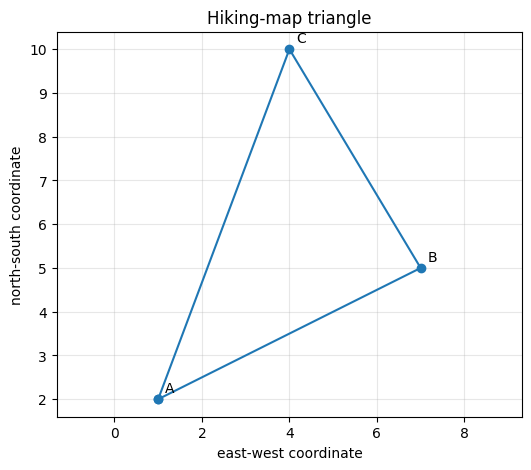

In [64]:
trail_points = [(1,2),(7,5),(4,10)]
print('Triangle area =', triangle_area(trail_points))

xs=[p[0] for p in trail_points]+[trail_points[0][0]]
ys=[p[1] for p in trail_points]+[trail_points[0][1]]
plt.figure(figsize=(6,5))
plt.plot(xs,ys,marker='o')
for label,(x,y) in zip(['A','B','C'],trail_points):
    plt.text(x+0.15,y+0.15,label)
plt.grid(alpha=0.3)
plt.axis('equal')
plt.title('Hiking-map triangle')
plt.xlabel('east-west coordinate')
plt.ylabel('north-south coordinate')
plt.show()

## Determinant equation of a line

A point $(x,y)$ lies on the line through $(x_1,y_1)$ and $(x_2,y_2)$ when

$$
\det\begin{bmatrix}
x&y&1\\
x_1&y_1&1\\
x_2&y_2&1
\end{bmatrix}=0.
$$

For travel-map points $(2,5)$ and $(8,17)$,

$$
\det\begin{bmatrix}
x&y&1\\2&5&1\\8&17&1
\end{bmatrix}=0.
$$

Expanding gives

$$
-12x+6y-6=0,
$$

or

$$
y=2x+1.
$$

### Classroom Question: Why Does the Line Determinant Equal Zero?

Why does

$$
\det\begin{bmatrix}
x&y&1\\
x_1&y_1&1\\
x_2&y_2&1
\end{bmatrix}=0
$$

express the condition that $(x,y)$ lies on the line through $(x_1,y_1)$ and $(x_2,y_2)$?

In [65]:
reveal_answer_key("concept-3.4-line", 'Reveal geometric explanation')

ToggleButton(value=False, button_style='info', description='Reveal geometric explanation', icon='eye', layout=…

In [66]:
x,y=sp.symbols('x y')
line_det=sp.Matrix([[x,y,1],[2,5,1],[8,17,1]]).det()
print('Determinant equation expands to:', sp.expand(line_det))
print('Solved for y:', sp.solve(sp.Eq(line_det,0),y)[0])

Determinant equation expands to: -12*x + 6*y - 6
Solved for y: 2*x + 1


## Volume of a tetrahedron

For four points in space, the tetrahedron volume is

$$
V=\frac16\left|
\det\begin{bmatrix}
x_1&y_1&z_1&1\\
x_2&y_2&z_2&1\\
x_3&y_3&z_3&1\\
x_4&y_4&z_4&1
\end{bmatrix}
\right|.
$$

For

$$
(0,0,0),\quad(2,0,0),\quad(0,3,0),\quad(0,0,5),
$$

we obtain

$$
V=\frac16|30|=5
$$

cubic units.

Tetrahedron volume = 5


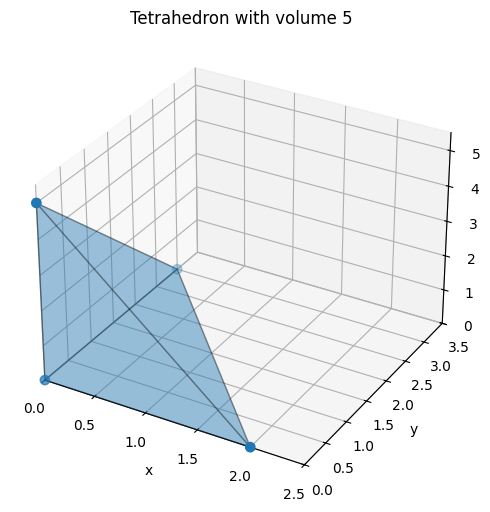

In [67]:
tetra_points=[(0,0,0),(2,0,0),(0,3,0),(0,0,5)]
print('Tetrahedron volume =', tetrahedron_volume(tetra_points))

from mpl_toolkits.mplot3d.art3d import Poly3DCollection
verts=np.array(tetra_points,dtype=float)
faces=[[verts[0],verts[1],verts[2]],[verts[0],verts[1],verts[3]],[verts[0],verts[2],verts[3]],[verts[1],verts[2],verts[3]]]
fig=plt.figure(figsize=(7,6))
ax=fig.add_subplot(111,projection='3d')
poly=Poly3DCollection(faces,alpha=0.25,edgecolor='black')
ax.add_collection3d(poly)
ax.scatter(verts[:,0],verts[:,1],verts[:,2],s=45)
ax.set_xlim(0,2.5); ax.set_ylim(0,3.5); ax.set_zlim(0,5.5)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Tetrahedron with volume 5')
plt.show()

## Equation of a plane through three points

A point $(x,y,z)$ lies in the plane through three noncollinear points when

$$
\det\begin{bmatrix}
x&y&z&1\\
x_1&y_1&z_1&1\\
x_2&y_2&z_2&1\\
x_3&y_3&z_3&1
\end{bmatrix}=0.
$$

Use the points

$$
P_1=(1,0,2),\qquad P_2=(3,1,0),\qquad P_3=(0,2,1).
$$

Vectors in the plane are

$$
P_2-P_1=(2,1,-2),
\qquad
P_3-P_1=(-1,2,-1).
$$

Their cross product is

$$
(2,1,-2)\times(-1,2,-1)=(3,4,5).
$$

Therefore, the plane has equation

$$
3(x-1)+4(y-0)+5(z-2)=0,
$$

or

$$
3x+4y+5z=13.
$$

A fourth point is coplanar with these three exactly when it satisfies this equation, equivalently when the corresponding $4\times4$ determinant is zero.

### Classroom Question: Plane Determinant and Coplanarity

Why does the $4\times4$ determinant used in the plane equation have to be zero when the fourth point lies in the same plane as the other three points?

In [53]:
reveal_answer_key("concept-3.4-plane", 'Reveal coplanarity explanation')

ToggleButton(value=False, button_style='info', description='Reveal coplanarity explanation', icon='eye', layou…

<IPython.core.display.Math object>

Plane expression = 3*x + 4*y + 5*z - 13


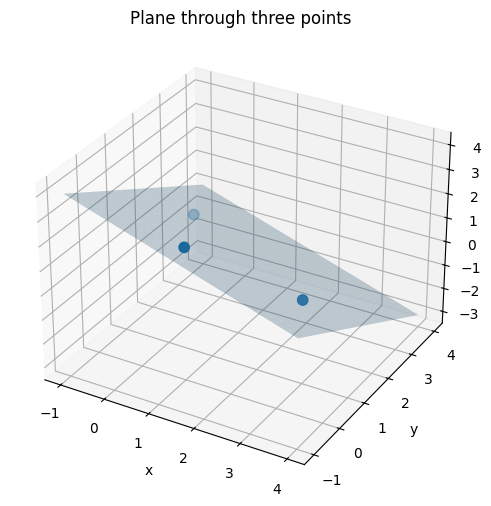

In [68]:
P1=sp.Matrix([1,0,2])
P2=sp.Matrix([3,1,0])
P3=sp.Matrix([0,2,1])
normal=(P2-P1).cross(P3-P1)
show_matrix(normal, 'n')
xx,yy,zz=sp.symbols('x y z')
plane_expr=sp.expand(normal.dot(sp.Matrix([xx,yy,zz])-P1))
print('Plane expression =', plane_expr)

# Plot the plane and the three points.
xgrid,ygrid=np.meshgrid(np.linspace(-1,4,30),np.linspace(-1,4,30))
zgrid=(13-3*xgrid-4*ygrid)/5
fig=plt.figure(figsize=(7,6))
ax=fig.add_subplot(111,projection='3d')
ax.plot_surface(xgrid,ygrid,zgrid,alpha=0.25)
pts=np.array([[1,0,2],[3,1,0],[0,2,1]],dtype=float)
ax.scatter(pts[:,0],pts[:,1],pts[:,2],s=55)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Plane through three points')
plt.show()

## Definitions and terminology

| Term | Meaning |
|---|---|
| Cofactor matrix | Matrix $[C_{ij}]$ |
| Adjugate | Transpose of the cofactor matrix |
| Adjugate inverse formula | $A^{-1}=\frac{1}{\det(A)}\operatorname{adj}(A)$ |
| Cramer's Rule | $x_i=\det(A_i)/\det(A)$ |
| Collinear | Points lying on one line |
| Coplanar | Points lying in one plane |
| Determinant line equation | $3\times3$ determinant equal to zero |
| Determinant plane equation | $4\times4$ determinant equal to zero |
| Tetrahedron volume | One sixth of an absolute $4\times4$ determinant |

## Section 3.4 worksheet — in-class practice

Work each problem before revealing the instructor solution.

### Problem 1

For

$$
A=\begin{bmatrix}2&1\\5&3\end{bmatrix},
$$

find $\operatorname{adj}(A)$ and $A^{-1}$.

In [55]:
reveal_answer_key("3.4-1", "Reveal Problem 1")

ToggleButton(value=False, button_style='info', description='Reveal Problem 1', icon='eye', layout=Layout(width…

### Problem 2

Use Cramer's Rule to solve

$$
\begin{cases}
x+y+z=9,\\
2x-y+z=5,\\
x+2y-z=4.
\end{cases}
$$

In [56]:
reveal_answer_key("3.4-2", "Reveal Problem 2")

ToggleButton(value=False, button_style='info', description='Reveal Problem 2', icon='eye', layout=Layout(width…

### Problem 3

Find the area of the triangle with vertices $(0,1)$, $(6,2)$, and $(2,7)$.

In [57]:
reveal_answer_key("3.4-3", "Reveal Problem 3")

ToggleButton(value=False, button_style='info', description='Reveal Problem 3', icon='eye', layout=Layout(width…

### Problem 4

Find an equation of the line through $(1,4)$ and $(5,12)$ using a determinant.

In [58]:
reveal_answer_key("3.4-4", "Reveal Problem 4")

ToggleButton(value=False, button_style='info', description='Reveal Problem 4', icon='eye', layout=Layout(width…

### Problem 5

Find the volume of the tetrahedron with vertices $(0,0,0)$, $(4,0,0)$, $(0,3,0)$, and $(0,0,2)$.

In [59]:
reveal_answer_key("3.4-5", "Reveal Problem 5")

ToggleButton(value=False, button_style='info', description='Reveal Problem 5', icon='eye', layout=Layout(width…

### Problem 6

Find an equation of the plane through $(1,1,0)$, $(3,0,1)$, and $(0,2,2)$.

In [60]:
reveal_answer_key("3.4-6", "Reveal Problem 6")

ToggleButton(value=False, button_style='info', description='Reveal Problem 6', icon='eye', layout=Layout(width…

# Chapter 3 Summary

Chapter 3 develops the determinant from a computational formula into a structural and geometric tool:

$$
\text{minors and cofactors}
\longrightarrow
\text{row-operation evaluation}
\longrightarrow
\text{invertibility and determinant properties}
\longrightarrow
\text{geometry and system-solving applications}.
$$

Core habits:

1. use $ad-bc$ only for $2\times2$ matrices;
2. choose sparse rows or columns for cofactor expansion;
3. track every row or column operation that affects the determinant;
4. remember the exponent in $\det(cA)=c^n\det(A)$;
5. connect $\det(A)=0$ with singularity, geometric collapse, and redundant rows or columns;
6. use absolute values for geometric area and volume;
7. remember that the sign records orientation;
8. use Python to verify calculations, not replace written reasoning.

> **Instructor closing note**
>
> The notebook intentionally contains more examples and applications than one class meeting can cover. Select core examples for lecture, use computational cells to reinforce geometry and structure, and use the reveal-enabled section worksheets for collaborative practice or short in-class checks.